# Project 3 - Bedbug Reporting in NYC
## Datasets to be used:
- **NYC Open Data – Bedbug Reporting:**

https://data.cityofnewyork.us/Housing-Development/Bedbug-Reporting/wz6d-d3jb

- **NYC Open Data – New York City Population by Borough (1950–2040):**

https://data.cityofnewyork.us/City-Government/New-York-City-Population-by-Borough-1950-2040/xywu-7bv9

- **2020 Neighborhood Tabulation Areas (NTAs) - Mapped:**

https://data.cityofnewyork.us/City-Government/2020-Neighborhood-Tabulation-Areas-NTAs-Mapped/4hft-v355



## Analysis question:
### At the borough level:
**After adjusting for population, are New Yorkers equally exposed to bedbug infestations across boroughs?**

### At the NTA (neighborhood) level:
- **Which neighborhoods are hotspots for exposure vs. hotspots for recurrence?**
- **Are these risks clustered in specific parts of the city?**

### Over time (2018–2024):
- **How have overall infestation filings changed by year?**
- **Did COVID or recent housing conditions influence the trend?**

## Columns that will be used:
### Bedbug dataset:
- `Borough`
- `of Dwelling Units`
- `Infested Dwelling Unit Count`
- `Re-infested Dwelling Unit Count`
- `Latitude`
- `Longitude`
- `NTA`
- `Filing Period End Date`

### Population dataset:
- `Borough`
- `2020 Population`

### Columns to be used to merge/join them:
- `Borough` (Bedbug dataset)
- `Borough` (Population dataset)
- `NTA` (Bedbug dataset)
- `NTA` (NTA geojson dataset)


## Hypothesis:
### H1 — Inequitable Borough Exposure
**Even after adjusting for population differences, outer boroughs (Bronx, Brooklyn, Queens) face higher resident-level exposure than Manhattan, reflecting differences in housing quality and enforcement.**

### H2 — Localized Hotspots
**Exposure and reinfestation are not geographically random — a few NTAs act as persistent hotspots while others remain low-risk.**

### H3 — Declining Trend
**Infestation filings declined after COVID-19 due to mobility changes, reduced inspections, or reporting fatigue.**


In [16]:
%pip install plotly


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import plotly.io as pio
pio.renderers.default = "notebook_connected+plotly_mimetype"

bedbug_path = "Bedbug_Reporting_20251205.csv"
bedbug = pd.read_csv(bedbug_path, low_memory=False)

pop_path = "New_York_City_Population_by_Borough,_1950_-_2040_20251205.csv"
population = pd.read_csv(pop_path, low_memory=False)

print("Bedbug columns:")
print(bedbug.columns.tolist())

print("\nPopulation columns:")
print(population.columns.tolist())


Bedbug columns:
['Building ID', 'Registration ID', 'Borough', 'House Number', 'Street Name', 'Postcode', '# of Dwelling Units', 'Infested Dwelling Unit Count', 'Eradicated Unit Count', 'Re-infested  Dwelling Unit Count', 'Filing Date', 'Filing Period Start Date', 'Filling Period End Date', 'Latitude', 'Longitude', 'Community Board', 'Council District', '2010 Census Tract', 'BIN', 'BBL', 'NTA']

Population columns:
['Age Group', 'Borough', '1950', '1950 - Boro share of NYC total', '1960', '1960 - Boro share of NYC total', '1970', '1970 - Boro share of NYC total', '1980', '1980 - Boro share of NYC total', '1990', '1990 - Boro share of NYC total', '2000', '2000 - Boro share of NYC total', '2010', '2010 - Boro share of NYC total', '2020', '2020 - Boro share of NYC total', '2030', '2030 - Boro share of NYC total', '2040', '2040 - Boro share of NYC total']


## Bedbug Exposure Risk

In [18]:
# Cleaning Bedbug Data
bedbug.columns = bedbug.columns.str.strip().str.replace(r"\s+", " ", regex=True)

bedbug = bedbug.rename(columns={
    "Building ID": "building_id",
    "Registration ID": "registration_id",
    "Borough": "borough",
    "# of Dwelling Units": "dwelling_units",
    "Infested Dwelling Unit Count": "infested_units",
    "Eradicated Unit Count": "eradicated_units",
    "Re-infested Dwelling Unit Count": "reinfested_units"
})

bb = bedbug[[
    "borough",
    "dwelling_units",
    "infested_units",
    "reinfested_units"
]].copy()

bb = bb[pd.to_numeric(bb["dwelling_units"], errors="coerce") > 0]

for col in ["dwelling_units", "infested_units", "reinfested_units"]:
    bb[col] = pd.to_numeric(bb[col], errors="coerce")

bb["borough"] = bb["borough"].str.upper()

bb.head(20)


,borough,dwelling_units,infested_units,reinfested_units
0,BROOKLYN,6,0,0
1,STATEN ISLAND,11,0,0
2,BROOKLYN,4,0,0
3,BROOKLYN,6,0,0
4,BROOKLYN,3,0,0
5,BROOKLYN,3,0,0
6,QUEENS,4,0,0
7,BROOKLYN,3,0,0
8,BROOKLYN,6,0,0
9,MANHATTAN,2,0,0


In [19]:
#groupby
bb_by_borough = (
    bb.groupby("borough", as_index=False)
    .agg({
        "dwelling_units": "sum",
        "infested_units": "sum",
        "reinfested_units": "sum"
    })
)

bb_by_borough["infestation_rate_per_unit"] = (
    bb_by_borough["infested_units"] / bb_by_borough["dwelling_units"]
)

bb_by_borough


,borough,dwelling_units,infested_units,reinfested_units,infestation_rate_per_unit
0,BRONX,2366515,13718,2395,0.005797
1,BROOKLYN,3541932,20932,3842,0.005910
2,MANHATTAN,5873509,23630,2694,0.004023
3,QUEENS,2891935,15732,2777,0.005440
4,STATEN ISLAND,126294,730,102,0.005780


In [20]:
#Clean Population Data
pop_clean = population.copy()
pop_clean.columns = pop_clean.columns.str.strip()

pop_2020 = pop_clean[["Borough", "2020"]].copy()
pop_2020 = pop_2020.rename(columns={
    "Borough": "borough",
    "2020": "total_population"
})

pop_2020["borough"] = pop_2020["borough"].str.strip().str.upper()

pop_2020 = pop_2020[pop_2020["borough"] != "NYC TOTAL"].copy()

pop_2020["total_population"] = (
    pop_2020["total_population"]
    .astype(str)
    .str.replace(",", "")
    .astype("int64")
)

pop_2020


,borough,total_population
1,BRONX,1446788
2,BROOKLYN,2648452
3,MANHATTAN,1638281
4,QUEENS,2330295
5,STATEN ISLAND,487155


In [21]:
#merge
merged = bb_by_borough.merge(pop_2020, on="borough", how="left")

merged["infested_units_per_10k_pop"] = (
    merged["infested_units"] / merged["total_population"] * 10000
)

merged


,borough,dwelling_units,infested_units,reinfested_units,infestation_rate_per_unit,total_population,infested_units_per_10k_pop
0,BRONX,2366515,13718,2395,0.005797,1446788,94.816932
1,BROOKLYN,3541932,20932,3842,0.005910,2648452,79.034848
2,MANHATTAN,5873509,23630,2694,0.004023,1638281,144.236550
3,QUEENS,2891935,15732,2777,0.005440,2330295,67.510766
4,STATEN ISLAND,126294,730,102,0.005780,487155,14.984964


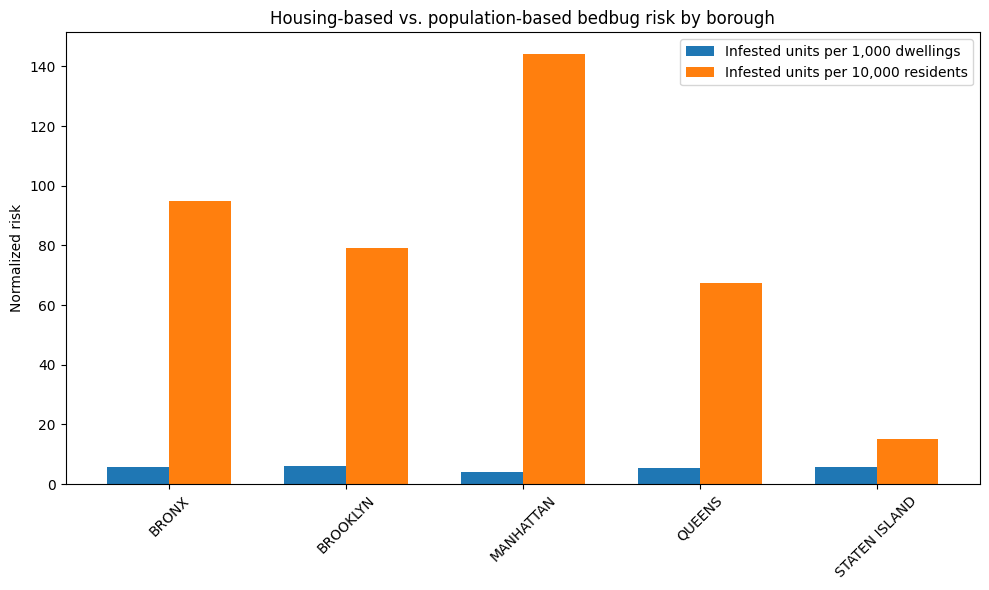

In [22]:
# Visualization
# per unit vs per capita
import matplotlib.pyplot as plt
import numpy as np

plot_df = merged.copy()

boroughs = plot_df["borough"]
x = np.arange(len(boroughs))

width = 0.35  

fig, ax = plt.subplots(figsize=(10,6))


rects1 = ax.bar(x - width/2,
                plot_df["infestation_rate_per_unit"]*1000,  
                width,
                label="Infested units per 1,000 dwellings")

rects2 = ax.bar(x + width/2,
                plot_df["infested_units_per_10k_pop"],
                width,
                label="Infested units per 10,000 residents")


ax.set_ylabel("Normalized risk")
ax.set_title("Housing-based vs. population-based bedbug risk by borough")
ax.set_xticks(x)
ax.set_xticklabels(boroughs, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()


### Interpretation

**Using bedbug reporting records from 2018–2025 and normalizing by borough-level population in 2020, the study finds substantial variation in bedbug exposure risk across New York City.**
- While Manhattan has the **lowest infestation risk per dwelling unit**, it has the **highest exposure risk per resident**. This demonstrates that population density amplifies bedbug burden, especially in Manhattan.


- **Manhattan** exhibits the highest exposure at **≈145** infested units per 10k residents, followed by the **Bronx (≈95)** and **Brooklyn (≈79)**. **Queens (≈68)** faces a moderate risk, while **Staten Island** experiences the lowest **(≈15)**.

These findings indicate that bedbug exposure is unevenly distributed, raising concerns about environmental health equity in NYC. Although Manhattan has relatively low infestation per housing unit, its dense population leads to a higher resident-level exposure burden, especially compared to outer boroughs.

## Reinfestation

In [23]:
# Reinfestation
bb_reinf = bb_by_borough.copy()

bb_reinf["reinfestation_share"] = (
    bb_reinf["reinfested_units"] / bb_reinf["infested_units"]
)

merged["reinfested_units_per_10k_pop"] = (
    merged["reinfested_units"] / merged["total_population"] * 10000
)

bb_reinf, merged[["borough", "reinfested_units_per_10k_pop"]]

(         borough  dwelling_units  infested_units  reinfested_units  \
 0          BRONX         2366515           13718              2395   
 1       BROOKLYN         3541932           20932              3842   
 2      MANHATTAN         5873509           23630              2694   
 3         QUEENS         2891935           15732              2777   
 4  STATEN ISLAND          126294             730               102   
 
    infestation_rate_per_unit  reinfestation_share  
 0                   0.005797             0.174588  
 1                   0.005910             0.183547  
 2                   0.004023             0.114008  
 3                   0.005440             0.176519  
 4                   0.005780             0.139726  ,
          borough  reinfested_units_per_10k_pop
 0          BRONX                     16.553911
 1       BROOKLYN                     14.506587
 2      MANHATTAN                     16.444065
 3         QUEENS                     11.916946
 4  STATEN IS

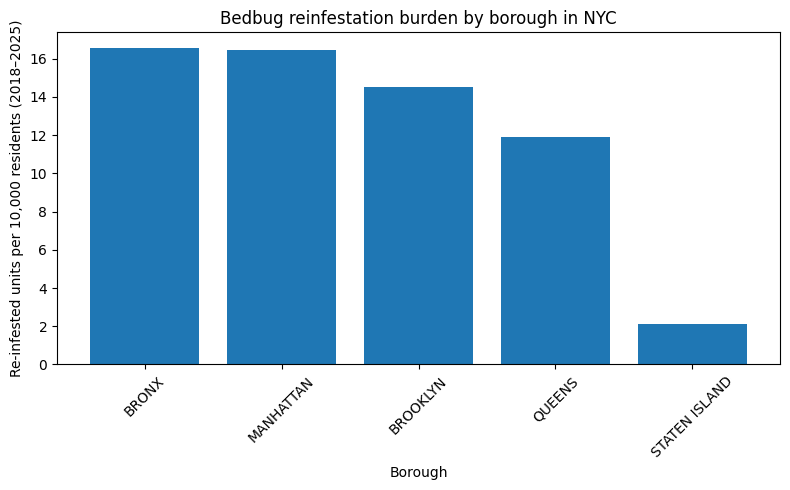

In [24]:
# Visualization
plot_df2 = merged.sort_values("reinfested_units_per_10k_pop", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df2["borough"], plot_df2["reinfested_units_per_10k_pop"])
plt.ylabel("Re-infested units per 10,000 residents (2018–2025)")
plt.xlabel("Borough")
plt.title("Bedbug reinfestation burden by borough in NYC")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

Reinfestation risk varies significantly across NYC boroughs.
- The **Bronx** and **Manhattan** show the **highest reinfested units** per 10,000 residents, followed closely by Brooklyn, while Staten Island remains very low.

# NTA Level

In [25]:
nta_df = bedbug[["NTA", "dwelling_units", "infested_units", "reinfested_units"]].copy()

nta_df = nta_df.dropna(subset=["NTA"])

for col in ["dwelling_units", "infested_units", "reinfested_units"]:
    nta_df[col] = pd.to_numeric(nta_df[col], errors="coerce")

nta_grouped = (
    nta_df.groupby("NTA", as_index=False)
    .agg({
        "dwelling_units": "sum",
        "infested_units": "sum",
        "reinfested_units": "sum"
    })
)

nta_grouped = nta_grouped[nta_grouped["dwelling_units"] > 0]

nta_grouped["infestation_rate_per_unit"] = (
    nta_grouped["infested_units"] / nta_grouped["dwelling_units"]
)

nta_grouped["reinfestation_share"] = (
    nta_grouped["reinfested_units"] / nta_grouped["infested_units"]
)

nta_grouped.head()

,NTA,dwelling_units,infested_units,reinfested_units,infestation_rate_per_unit,reinfestation_share
0,Allerton,51069.0,270.0,41.0,0.005287,0.151852
1,Annadale-Huguenot-Prince's Bay-Woodrow,102.0,0.0,0.0,0.000000,NaN
2,Arden Heights-Rossville,88.0,0.0,0.0,0.000000,NaN
3,Astoria (Central),119329.0,593.0,117.0,0.004969,0.197302
4,Astoria (East)-Woodside (North),57642.0,294.0,84.0,0.005100,0.285714


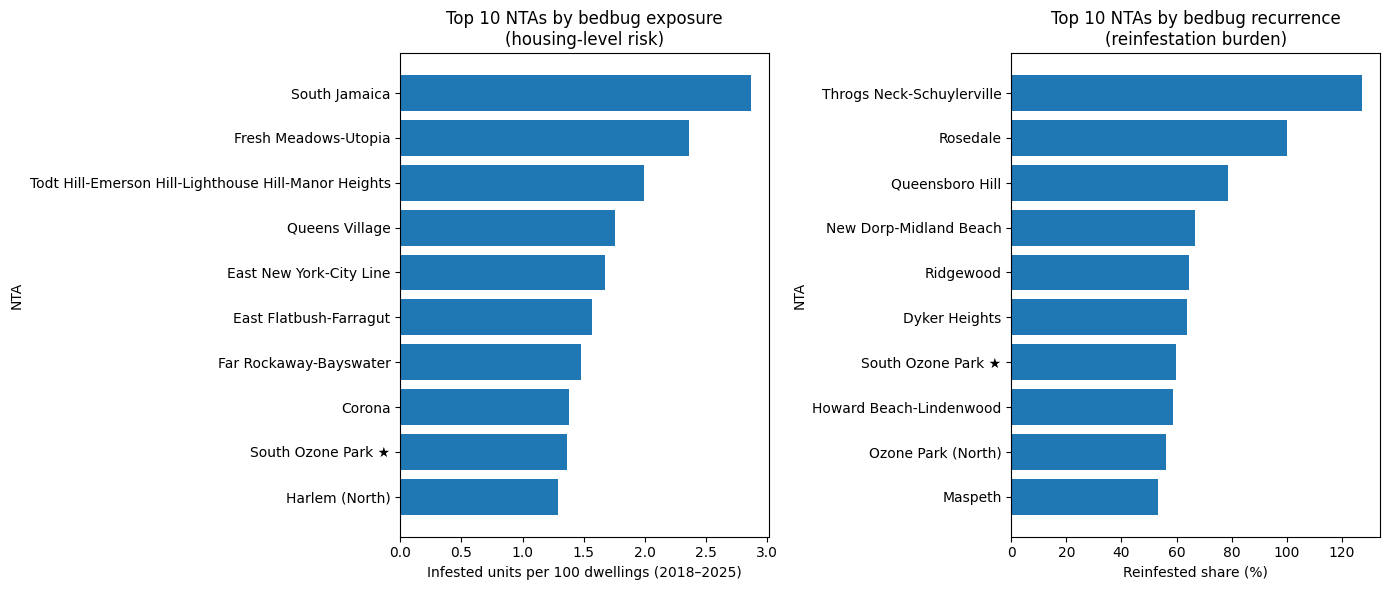

In [26]:
import matplotlib.pyplot as plt

top10_unit = (
    nta_grouped
    .sort_values("infestation_rate_per_unit", ascending=False)
    .head(10)
    .copy()
)

top10_re = (
    nta_grouped
    .dropna(subset=["reinfestation_share"])  
    .sort_values("reinfestation_share", ascending=False)
    .head(10)
    .copy()
)

overlap = set(top10_unit["NTA"]).intersection(set(top10_re["NTA"]))

top10_unit["label"] = top10_unit["NTA"].where(
    ~top10_unit["NTA"].isin(overlap),
    top10_unit["NTA"] + " ★"
)

top10_re["label"] = top10_re["NTA"].where(
    ~top10_re["NTA"].isin(overlap),
    top10_re["NTA"] + " ★"
)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top10_unit["label"], top10_unit["infestation_rate_per_unit"] * 100)
axes[0].invert_yaxis()
axes[0].set_xlabel("Infested units per 100 dwellings (2018–2025)")
axes[0].set_ylabel("NTA")
axes[0].set_title("Top 10 NTAs by bedbug exposure\n(housing-level risk)")

axes[1].barh(top10_re["label"], top10_re["reinfestation_share"] * 100)
axes[1].invert_yaxis()
axes[1].set_xlabel("Reinfested share (%)")
axes[1].set_ylabel("NTA")
axes[1].set_title("Top 10 NTAs by bedbug recurrence\n(reinfestation burden)")

plt.tight_layout()
plt.show()


### Interpretation

- Exposure risk is highly concentrated in several **Queens and Brooklyn** neighborhoods: 
**South Jamaica, Fresh Meadows–Utopia, and East Flatbush–Farragut** face the highest housing-level infestation rates.

- The comparison shows a striking **mismatch between exposure risk and recurrence risk** across NYC neighborhoods.

    - While most high-exposure areas are in Queens and Brooklyn, **South Ozone Park (★)** is the only neighborhood that appears in both top-10 lists.

    - The residents there are not only at high risk of initially encountering bedbugs, but also face one of the city’s greatest burdens of reinfestation, a double impact of poor housing conditions and ineffective pest control.


- Compared to Manhattan—where population density inflates resident-level exposure, these communities show severe infestation despite having lower density, suggesting failures in housing maintenance, landlord accountability, and enforcement in specific areas.

# Choropleth Visualization

In [27]:
import geopandas as gpd

nta_path = "2020_Neighborhood_Tabulation_Areas_(NTAs)_20251205.geojson" 
nta_gdf = gpd.read_file(nta_path)

print(nta_gdf.columns)
print(nta_gdf.head(1))


Index([':id', ':version', ':created_at', ':updated_at', 'borocode', 'boroname',
       'countyfips', 'nta2020', 'ntaname', 'ntaabbrev', 'ntatype', 'cdta2020',
       'cdtaname', 'shape_leng', 'shape_area', 'geometry'],
      dtype='object')
                  :id           :version                      :created_at  \
0  row-9rke~8csg~x32h  rv-iaad~hgin.v282 2025-11-24 21:27:53.701000+00:00   

                       :updated_at borocode  boroname countyfips nta2020  \
0 2025-11-24 21:27:53.701000+00:00        3  Brooklyn        047  BK0101   

      ntaname ntaabbrev ntatype cdta2020  \
0  Greenpoint     Grnpt       0     BK01   

                                         cdtaname     shape_leng  \
0  BK01 Williamsburg-Greenpoint (CD 1 Equivalent)  28919.5611508   

      shape_area                                           geometry  
0  35321808.3909  MULTIPOLYGON (((-73.93213 40.72816, -73.93238 ...  


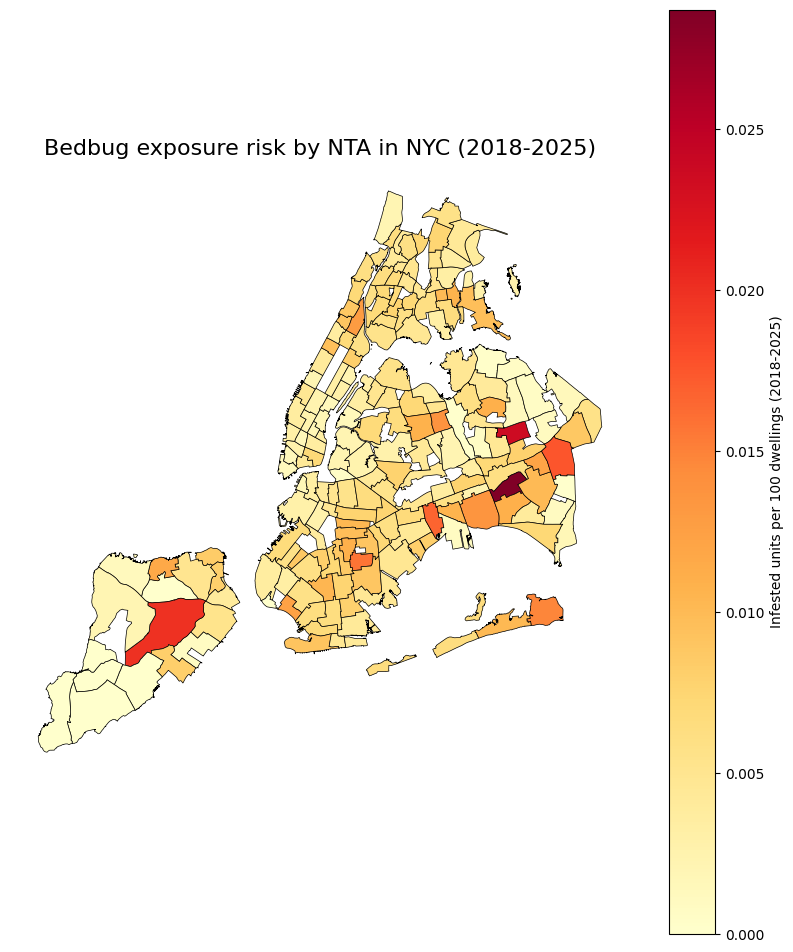

In [28]:
import matplotlib.pyplot as plt

map_df = nta_grouped.copy()

map_df["NTA"] = map_df["NTA"].str.upper()
nta_gdf["ntaname"] = nta_gdf["ntaname"].str.upper()

# Merge
merged_map = nta_gdf.merge(
    map_df,
    left_on="ntaname",
    right_on="NTA",
    how="left"
)

# Visualization
fig, ax = plt.subplots(figsize=(10, 12))

merged_map.plot(
    column="infestation_rate_per_unit",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label": "Infested units per 100 dwellings (2018-2025)",
        "orientation": "vertical"
    },
    ax=ax
)

ax.set_title("Bedbug exposure risk by NTA in NYC (2018-2025)", fontsize=16)
ax.axis("off")
plt.show()


| Area / Borough Pattern | Risk Characteristics | Possible Interpretation |
|---|---|---|
| Several neighborhoods in South-Central Brooklyn (dark red hotspots) | High-density clusters of infestation | Older multi-unit housing stock, high rental share, higher tenant turnover contributing to spread |
| Southeastern Queens | Moderately elevated risk | Risk of faster spread; requires attention to early intervention |
| One neighborhood in Southwestern Staten Island | Localized high-risk hotspot | Suggests a localized outbreak rather than borough-wide issue |
| Many areas in Manhattan & the Bronx | Relatively lower exposure burden | Better building conditions, stronger property management compliance, and resource availability |

# By Year

In [29]:
bb_year = bedbug[["Filling Period End Date", "infested_units"]].copy()

bb_year["period_end"] = pd.to_datetime(bb_year["Filling Period End Date"], errors="coerce")
bb_year["year"] = bb_year["period_end"].dt.year

bb_year = bb_year.dropna(subset=["year"])
bb_year["infested_units"] = pd.to_numeric(bb_year["infested_units"], errors="coerce")

bb_by_year = (
    bb_year.groupby("year", as_index=False)["infested_units"]
    .sum()
    .sort_values("year")
)

bb_by_year

,year,infested_units
0,2018.0,15937.0
1,2019.0,11303.0
2,2020.0,13758.0
3,2021.0,9424.0
4,2022.0,9512.0
5,2023.0,8215.0
6,2024.0,7524.0


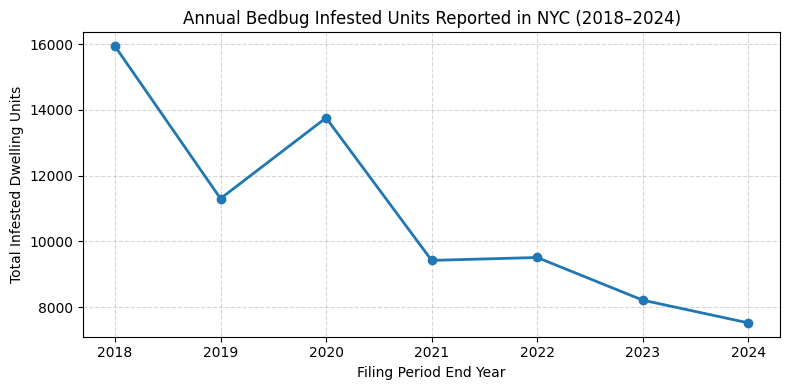

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(bb_by_year["year"], bb_by_year["infested_units"],
         marker="o", linewidth=2)

plt.title("Annual Bedbug Infested Units Reported in NYC (2018–2024)")
plt.xlabel("Filing Period End Year")
plt.ylabel("Total Infested Dwelling Units")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(bb_by_year["year"])
plt.tight_layout()
plt.show()


### Interpetation
- Bedbug infestation reports in New York City show a noticeable **downward trend over time**. 

- Following a high point in 2018 (15,937 infested units), reports **declined through 2019**, briefly **rebounded in 2020** during the COVID-19 pandemic, and then continued to **fall steadily from 2021 to 2024**.

This suggests that overall exposure risk has gradually improved citywide in recent years, although reporting behaviors during the pandemic may partially explain fluctuations.

# Conclusion
This analysis provides a spatial and temporal overview of bedbug infestation risks in New York City based on aggregated filing records from 2018 to 2025. Three consistent insights emerge across borough-level patterns, neighborhood-level clustering, and year-to-year dynamics:

**1. Overall exposure risk has improved over time.**
Annual reports of infested dwelling units decreased steadily from 2018 to 2024, with only a temporary spike in 2020. The COVID-19 pandemic likely disrupted reporting and inspection processes, but the long-term direction suggests continued progress in bedbug management citywide.

**2. Risk remains unevenly distributed across boroughs.**
Manhattan shows the highest resident-level burden (infested units per 10,000 residents), largely due to population density and housing concentration, even though its infestation rate per dwelling unit is not the highest. The Bronx and Brooklyn also face relatively elevated risks compared to Queens and Staten Island.

**3. Reinfestation patterns reveal vulnerability in specific communities.**
While initial exposure is widespread, reinfestation risk is highly localized, forming clusters in outer-borough neighborhoods such as Throgs Neck–Schuylerville and Rosedale. These areas may suffer from persistent structural or socioeconomic barriers that limit effective remediation.
